In [1]:
import pandas as pd

df = pd.read_excel("DF_FINAL.xlsx")

df.head()

calles_base = [
    "Avenida de la Ilustración (M-30)",
    "Avenida del Manzanares (M-30)",
    "Avenida de Valladolid",
    "Avenida de Logroño",
    "Avenida Reina Victoria",
    "Calle Bravo Murillo",
    "Calle Cea Bermúdez",
    "Calle Raimundo Fernández Villaverde",
    "Calle San Bernardo",
    "Calle Sinesio Delgado",
    "Francos Rodríguez",
    "Paseo de San Francisco de Sales"
]

calles_noroeste = []

for base in calles_base:
    for col in df.columns:
        if base in col:
            calles_noroeste.append(col)

L = 3  # número de lags

X = pd.DataFrame()

for street in calles_noroeste:
    for lag in range(1, L + 1):
        X[f"{street}_t-{lag}"] = df[street].shift(lag)

# Variables externas reales
X["AEMET_tmed"] = df["AEMET_tmed"]
X["AEMET_prec"] = df["AEMET_prec"]
X["dia_semana"] = df["dia_semana"]
X["festivo"] = df["festivo"]

# Convertir variables categóricas a numéricas
X["dia_semana"] = X["dia_semana"].map({
    "lunes": 0,
    "martes": 1,
    "miércoles": 2,
    "jueves": 3,
    "viernes": 4,
    "sábado": 5,
    "domingo": 6
})

X["festivo"] = X["festivo"].map({
    "no": 0,
    "sí": 1
})


y_col = [col for col in df.columns if "Calle Sinesio Delgado" in col][0]
y = df[y_col]

# Limpiar NaNs
X = X.dropna()
y = y.loc[X.index]

In [2]:
split = int(len(X) * 0.8)

X_train = X.iloc[:split]
X_test  = X.iloc[split:]

y_train = y.iloc[:split]
y_test  = y.iloc[split:]

In [3]:
X_train

,Avenida de la Ilustración (M-30)_E-O_t-1,Avenida de la Ilustración (M-30)_E-O_t-2,Avenida de la Ilustración (M-30)_E-O_t-3,Avenida de la Ilustración (M-30)_O-E_t-1,Avenida de la Ilustración (M-30)_O-E_t-2,Avenida de la Ilustración (M-30)_O-E_t-3,Avenida del Manzanares (M-30)_E-O_t-1,Avenida del Manzanares (M-30)_E-O_t-2,Avenida del Manzanares (M-30)_E-O_t-3,Avenida del Manzanares (M-30)_N-S_t-1,...,Francos Rodríguez_E-O_t-1,Francos Rodríguez_E-O_t-2,Francos Rodríguez_E-O_t-3,Francos Rodríguez_O-E_t-1,Francos Rodríguez_O-E_t-2,Francos Rodríguez_O-E_t-3,AEMET_tmed,AEMET_prec,dia_semana,festivo
3,202.0,282.0,421.0,194.0,320.0,495.0,1575.0,2578.0,3177.0,340.0,...,40.0,57.0,81.0,32.0,57.0,68.0,19.6,0.0,4.0,0.0
4,92.0,202.0,282.0,79.0,194.0,320.0,959.0,1575.0,2578.0,170.0,...,43.0,40.0,57.0,36.0,32.0,57.0,19.6,0.0,4.0,0.0
5,61.0,92.0,202.0,63.0,79.0,194.0,771.0,959.0,1575.0,127.0,...,35.0,43.0,40.0,25.0,36.0,32.0,19.6,0.0,4.0,0.0
6,84.0,61.0,92.0,66.0,63.0,79.0,789.0,771.0,959.0,150.0,...,40.0,35.0,43.0,31.0,25.0,36.0,19.6,0.0,4.0,0.0
7,124.0,84.0,61.0,108.0,66.0,63.0,1417.0,789.0,771.0,678.0,...,56.0,40.0,35.0,83.0,31.0,25.0,19.6,0.0,4.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
25046,1783.0,1689.0,1758.0,1673.0,1597.0,1542.0,8366.0,7505.0,7876.0,3423.0,...,210.0,181.0,153.0,160.0,138.0,170.0,32.2,0.0,4.0,0.0
25047,1778.0,1783.0,1689.0,1907.0,1673.0,1597.0,9999.0,8366.0,7505.0,3611.0,...,250.0,210.0,181.0,148.0,160.0,138.0,32.2,0.0,4.0,0.0
25048,2245.0,1778.0,1783.0,2606.0,1907.0,1673.0,9999.0,9999.0,8366.0,4743.0,...,153.0,250.0,210.0,130.0,148.0,160.0,32.2,0.0,4.0,0.0
25049,2188.0,2245.0,1778.0,2855.0,2606.0,1907.0,9999.0,9999.0,9999.0,150.0,...,89.0,153.0,250.0,98.0,130.0,148.0,32.2,0.0,4.0,0.0


In [4]:
with pd.ExcelWriter("dataset_modelo.xlsx") as writer:
    X_train.to_excel(writer, sheet_name="X_train")
    X_test.to_excel(writer, sheet_name="X_test")
    y_train.to_excel(writer, sheet_name="y_train")
    y_test.to_excel(writer, sheet_name="y_test")

In [5]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(
    n_estimators=400,
    max_depth=10,
    min_samples_leaf=20,
    random_state=0,
    n_jobs=-1
)

rf.fit(X_train, y_train)

RandomForestRegressor(max_depth=10, min_samples_leaf=20, n_estimators=400,
                      n_jobs=-1, random_state=0)

In [6]:
# Predicción en test
y_pred = rf.predict(X_test)

# Predicción próxima hora
X_next = X.iloc[[-1]]
y_next = rf.predict(X_next)

print("Predicción tráfico en Sinesio Delgado (E-O) próxima hora:", y_next[0])

Predicción tráfico en Sinesio Delgado (E-O) próxima hora: 239.8457266753898


In [7]:
import numpy as np
from sklearn.metrics import mean_absolute_error, mean_squared_error

# Cálculo de métricas
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

def mape(y_true, y_pred, eps=1e-6):
    return np.mean(np.abs((y_true - y_pred) / (y_true + eps))) * 100

mape_val = mape(y_test, y_pred)

print(f"MAE: {mae:.2f}")
print(f"RMSE: {rmse:.2f}")
print(f"MAPE: {mape_val:.2f} %")

MAE: 39.72
RMSE: 58.62
MAPE: 12.21 %


In [8]:
importances = pd.Series(
    rf.feature_importances_,
    index=X_train.columns
).sort_values(ascending=False)

print(importances.head(10))

Avenida Reina Victoria_O-E_t-1                 0.703935
Avenida de Logroño_E-O_t-1                     0.102200
Avenida de Logroño_O-E_t-1                     0.076865
Calle Sinesio Delgado_E-O_t-1                  0.032340
Avenida Reina Victoria_E-O_t-1                 0.030918
Calle Raimundo Fernández Villaverde_E-O_t-1    0.026081
Francos Rodríguez_E-O_t-1                      0.002405
Avenida de Logroño_E-O_t-2                     0.001884
Avenida Reina Victoria_O-E_t-2                 0.001541
Calle Raimundo Fernández Villaverde_O-E_t-1    0.001523
dtype: float64


In [9]:
from sklearn.inspection import permutation_importance

perm = permutation_importance(
    rf,
    X_test,
    y_test,
    n_repeats=10,
    random_state=0,
    n_jobs=-1,
    scoring="neg_mean_absolute_error"
)

perm_df = pd.DataFrame({
    "feature": X_test.columns,
    "importance": perm.importances_mean
}).sort_values("importance", ascending=False)

perm_df.head(10)


,feature,importance
33,Avenida Reina Victoria_O-E_t-1,110.654429
27,Avenida de Logroño_O-E_t-1,47.872495
57,Calle Sinesio Delgado_E-O_t-1,36.549382
24,Avenida de Logroño_E-O_t-1,25.914928
45,Calle Raimundo Fernández Villaverde_E-O_t-1,17.372831
30,Avenida Reina Victoria_E-O_t-1,8.625038
25,Avenida de Logroño_E-O_t-2,2.937749
60,Calle Sinesio Delgado_O-E_t-1,2.191047
10,Avenida del Manzanares (M-30)_N-S_t-2,1.755402
48,Calle Raimundo Fernández Villaverde_O-E_t-1,1.165730


In [10]:
top_k = 8
top_features = perm_df.head(top_k)
top_features


,feature,importance
33,Avenida Reina Victoria_O-E_t-1,110.654429
27,Avenida de Logroño_O-E_t-1,47.872495
57,Calle Sinesio Delgado_E-O_t-1,36.549382
24,Avenida de Logroño_E-O_t-1,25.914928
45,Calle Raimundo Fernández Villaverde_E-O_t-1,17.372831
30,Avenida Reina Victoria_E-O_t-1,8.625038
25,Avenida de Logroño_E-O_t-2,2.937749
60,Calle Sinesio Delgado_O-E_t-1,2.191047


In [11]:
top_streets = (
    top_features["feature"]
    .str.split("_")
    .str[0]
    .value_counts()
)
top_streets

feature
Avenida de Logroño                     3
Avenida Reina Victoria                 2
Calle Sinesio Delgado                  2
Calle Raimundo Fernández Villaverde    1
Name: count, dtype: int64

In [12]:
from pathlib import Path

# Cambiar estos dos valores en cada notebook
modelo = "RF"
calle = "Calle Sinesio Delgado"

# Carpeta donde se guardarán las importancias
output_dir = Path("importancias_variables")
output_dir.mkdir(exist_ok=True)

# Guardar todas las variables, no solo el top 10
perm_df_export = perm_df.copy()
perm_df_export["modelo"] = modelo
perm_df_export["calle"] = calle

# Nombre limpio para el archivo
nombre_archivo = f"{modelo}_{calle}".replace(" ", "_").replace("á", "a").replace("é", "e")
nombre_archivo = nombre_archivo.replace("í", "i").replace("ó", "o").replace("ú", "u")

perm_df_export.to_csv(output_dir / f"{nombre_archivo}.csv", index=False)

print(f"Archivo guardado: {output_dir / f'{nombre_archivo}.csv'}")

Archivo guardado: importancias_variables\RF_Calle_Sinesio_Delgado.csv


In [13]:
calle_objetivo = "Calle Sinesio Delgado"   # cámbialo según el notebook
modelo = "RF"                # opcional, para tenerlo identificado

In [14]:
import pandas as pd
import unicodedata

def normalizar_texto(texto):
    texto = str(texto).lower()
    texto = ''.join(
        c for c in unicodedata.normalize('NFD', texto)
        if unicodedata.category(c) != 'Mn'
    )
    return texto

def clasificar_variable(feature, calle_objetivo):
    f = normalizar_texto(feature)
    calle = normalizar_texto(calle_objetivo)

    # Variables meteorológicas
    if any(palabra in f for palabra in [
        'aemet', 'tmed', 'temp', 'temperatura', 'prec', 'precipitacion',
        'humedad', 'viento', 'presion', 'radiacion'
    ]):
        return 'Variables meteorológicas'

    # Variables de calendario
    if any(palabra in f for palabra in [
        'dia_semana', 'festivo', 'mes', 'hora', 'fin_semana'
    ]):
        return 'Variables de calendario'

    # Retardos de la propia calle
    if calle in f:
        return 'Retardos propia calle'

    # Resto de variables de tráfico
    return 'Retardos otras calles'

In [15]:
perm_df_aux = perm_df.copy()

perm_df_aux["modelo"] = modelo
perm_df_aux["calle"] = calle_objetivo

perm_df_aux["tipo_variable"] = perm_df_aux["feature"].apply(
    lambda x: clasificar_variable(x, calle_objetivo)
)

perm_df_aux.head(15)

,feature,importance,modelo,calle,tipo_variable
33,Avenida Reina Victoria_O-E_t-1,110.654429,RF,Calle Sinesio Delgado,Retardos otras calles
27,Avenida de Logroño_O-E_t-1,47.872495,RF,Calle Sinesio Delgado,Retardos otras calles
57,Calle Sinesio Delgado_E-O_t-1,36.549382,RF,Calle Sinesio Delgado,Retardos propia calle
24,Avenida de Logroño_E-O_t-1,25.914928,RF,Calle Sinesio Delgado,Retardos otras calles
45,Calle Raimundo Fernández Villaverde_E-O_t-1,17.372831,RF,Calle Sinesio Delgado,Retardos otras calles
30,Avenida Reina Victoria_E-O_t-1,8.625038,RF,Calle Sinesio Delgado,Retardos otras calles
25,Avenida de Logroño_E-O_t-2,2.937749,RF,Calle Sinesio Delgado,Retardos otras calles
60,Calle Sinesio Delgado_O-E_t-1,2.191047,RF,Calle Sinesio Delgado,Retardos propia calle
10,Avenida del Manzanares (M-30)_N-S_t-2,1.755402,RF,Calle Sinesio Delgado,Retardos otras calles
48,Calle Raimundo Fernández Villaverde_O-E_t-1,1.165730,RF,Calle Sinesio Delgado,Retardos otras calles


In [16]:
perm_df_aux["importance_pos"] = perm_df_aux["importance"].clip(lower=0)

In [17]:
resumen_tipos = (
    perm_df_aux
    .groupby("tipo_variable")["importance_pos"]
    .sum()
    .reset_index()
)

resumen_tipos["porcentaje"] = (
    100 * resumen_tipos["importance_pos"] / resumen_tipos["importance_pos"].sum()
)

resumen_tipos = resumen_tipos.sort_values("porcentaje", ascending=False)

resumen_tipos

,tipo_variable,importance_pos,porcentaje
0,Retardos otras calles,229.900137,84.987333
1,Retardos propia calle,40.373146,14.924767
2,Variables de calendario,0.149056,0.055102
3,Variables meteorológicas,0.088724,0.032799


In [18]:
meteo_df = perm_df_aux[perm_df_aux["tipo_variable"] == "Variables meteorológicas"] \
    .sort_values("importance", ascending=False)

meteo_df.head(20)

,feature,importance,modelo,calle,tipo_variable,importance_pos
69,AEMET_tmed,0.088215,RF,Calle Sinesio Delgado,Variables meteorológicas,0.088215
70,AEMET_prec,0.000509,RF,Calle Sinesio Delgado,Variables meteorológicas,0.000509


In [19]:
meteo_total = meteo_df["importance_pos"].sum()
print("Importancia positiva acumulada de meteorología:", meteo_total)

Importancia positiva acumulada de meteorología: 0.08872420817225261


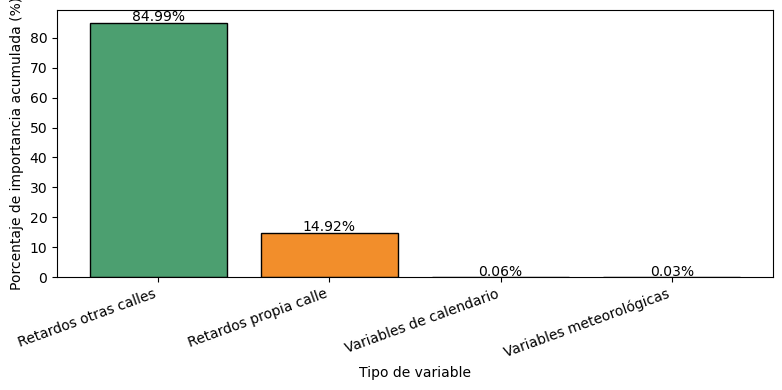

In [20]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 4))

plt.bar(resumen_tipos["tipo_variable"], resumen_tipos["porcentaje"],
        color=['#4C9F70', '#F28E2B', '#8E63CE', '#BDBDBD'],
        edgecolor='black')

plt.ylabel("Porcentaje de importancia acumulada (%)")
plt.xlabel("Tipo de variable")

for i, v in enumerate(resumen_tipos["porcentaje"]):
    plt.text(i, v + 0.5, f"{v:.2f}%", ha='center')

plt.xticks(rotation=20, ha='right')
plt.tight_layout()
plt.show()